# PINN for shape optimization of a super-ellipse in steady-state Navier Stokes flow:

### This is a work in progress...

#### Progress till 03-26-2020 - > Qualitative results on PINN for fixed shaped Ellipse in steady NV flow (Re = 4)

In [1]:


import numpy as np 
import matplotlib.pyplot as plt 
import os 
import torch 

import torch.nn as nn 
import torch.optim as optim 
import pandas as pd 
import wandb 

from scipy.stats import qmc



## Vanila PINN:

In [2]:
class PINN(nn.Module):
    def __init__(self, input_dim=5, output_dim=5): # Output: psi, p, s11, s22, s12
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Mish(),
            nn.Linear(64, 128),
            nn.Mish(),
            nn.Linear(128, 64),
            nn.Mish(),
            nn.Linear(64, output_dim)
        )
        
        
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x, y, a, b, n, sdf):
        inputs = torch.cat([x, y, a, b, n], dim=1)
        raw_out = self.net(inputs)
        
        psi = raw_out[:, 0:1] # Stream function
        p   = raw_out[:, 1:2] # Pressure
        s11 = raw_out[:, 2:3] # Stress xx
        s22 = raw_out[:, 3:4] # Stress yy
        s12 = raw_out[:, 4:5] # Stress xy
        
        
        u = compute_grad(psi, y)
        v = -compute_grad(psi, x)
        
        
        return u, v, p, psi, s11, s22, s12

def compute_grad(outputs, inputs):
    """Computes dy/dx using PyTorch Autograd."""
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]

##  Fourier features based PINN :


In [ ]:


# fourier features extractor:
class fourier_features(nn.Module):
    def __init__(self, spatial_dim=2, n_fourier_features=64, sigma=1.0):
        super().__init__()
      
        b_matrix = torch.normal(0, sigma, size=(spatial_dim, n_fourier_features // 2))
        self.register_buffer('B', b_matrix)

    def forward(self, x_spatial):
        
        projection = torch.matmul(x_spatial, self.B)
        return torch.cat([torch.sin(projection), torch.cos(projection)], dim=-1)


# Fourier features PINN :
class fourier_PINN(nn.Module):
    def __init__(self, n_fourier_features=64, shape_dim=3, output_dim=5): 
        super().__init__()
        
        self.fourier_features = fourier_features(spatial_dim=2, n_fourier_features=n_fourier_features, sigma=1.0)
        
        linear_input_dim = n_fourier_features + shape_dim
        
        self.net = nn.Sequential(
            nn.Linear(linear_input_dim, 128),
            nn.Mish(),
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 64),
            nn.Mish(),
            nn.Linear(64, output_dim)
        )    

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x, y, a, b, n, sdf):
        x_norm = (x - 2.0) / 10.0
        y_norm = y / 8.0
        
        spatial_inputs = torch.cat([x_norm, y_norm], dim=1)
        spatial_ff = self.fourier_features(spatial_inputs)
        
        inputs = torch.cat([spatial_ff, a, b, n], dim=1)
        
        raw_out = self.net(inputs)
        
        psi_net = raw_out[:, 0:1] 
        p       = raw_out[:, 1:2] 
        s11     = raw_out[:, 2:3] 
        s22     = raw_out[:, 3:4] 
        s12     = raw_out[:, 4:5] 
        

        # Parabolic freestream: u = 1 - (y^2)/64
        psi_base = y - (y**3) / 192.0
        psi = psi_base + psi_net
        
        u = compute_grad(psi, y)
        v = -compute_grad(psi, x)
        
        return u, v, p, psi, s11, s22, s12

def compute_grad(outputs, inputs):
    """Computes dy/dx using PyTorch Autograd."""
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]

## PDE loss calclation

In [4]:
def physics_loss(model, x, y, a, b, n, sdf, Re=4.0):

    u, v, p, psi, s11, s22, s12 = model(x, y, a, b, n, sdf)

    # fluid properties (non-dimensionalized):
    rho = 1.0
    mu = 1.0 / Re

    # dv/dx:
    u_x = compute_grad(u, x)
    u_y = compute_grad(u, y)
    v_x = compute_grad(v, x)
    v_y = compute_grad(v, y)
    
    # first derivatives of stress:
    s11_x = compute_grad(s11, x)
    s22_y = compute_grad(s22, y)
    s12_x = compute_grad(s12, x)
    s12_y = compute_grad(s12, y)
    
    # Constitutive laws: 
    f_s11 = -p + 2 * mu * u_x - s11
    f_s22 = -p + 2 * mu * v_y - s22
    f_s12 = mu * (u_y + v_x) - s12
    
    # 4. Momentum Equations :
    f_u = rho * (u * u_x + v * u_y) - s11_x - s12_y
    f_v = rho * (u * v_x + v * v_y) - s12_x - s22_y
    
    # we onlt wannt to evaluate the physics outside the obstacle...
    fluid_mask = (sdf > 0).detach()
    
    #losses:
    loss_s11 = torch.mean(f_s11[fluid_mask]**2)
    loss_s22 = torch.mean(f_s22[fluid_mask]**2)
    loss_s12 = torch.mean(f_s12[fluid_mask]**2)
    loss_u = torch.mean(f_u[fluid_mask]**2)
    loss_v = torch.mean(f_v[fluid_mask]**2)
    
    total_physics_loss = loss_s11 + loss_s22 + loss_s12 + loss_u + loss_v 
    
    return total_physics_loss, loss_u, loss_v, u, v, p 

## Collocation points sampling:

In [ ]:
# Latent Hypercube sampling:



def generate_collocation_points(N_points, a_val, b_val, n_val):
    """Generates 60% LHS points and 40% boundary-clustered points"""
    
    #  Background 60% points:
    N_lhs = int(N_points * 0.6)
    sampler = qmc.LatinHypercube(d=2)
    sample = sampler.random(n=N_lhs)
    
    x_lhs = (sample[:, 0] * 20.0) - 8.0
    y_lhs = (sample[:, 1] * 16.0) - 8.0

    # Dense Boundary Clustering (40%  points):
    N_bnd = N_points - N_lhs
    theta = np.random.uniform(0, 2*np.pi, N_bnd)
    
    x_shape = a_val * np.sign(np.cos(theta)) * np.abs(np.cos(theta))**(2/n_val)
    y_shape = b_val * np.sign(np.sin(theta)) * np.abs(np.sin(theta))**(2/n_val)
    
    x_clust = x_shape + np.random.normal(0, 0.15, N_bnd)
    y_clust = y_shape + np.random.normal(0, 0.15, N_bnd)

    x_combined = np.concatenate([x_lhs, x_clust])
    y_combined = np.concatenate([y_lhs, y_clust])

    x = torch.tensor(x_combined, dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(y_combined, dtype=torch.float32).unsqueeze(1)
    
    a = torch.full((N_points, 1), float(a_val))
    b = torch.full((N_points, 1), float(b_val))
    n = torch.full((N_points, 1), float(n_val))
    
    eps = 1e-6
    sdf = torch.pow((torch.abs(x/a) + eps)**n + (torch.abs(y/b) + eps)**n, 1/n) - 1.0
    
    x.requires_grad_(True)
    y.requires_grad_(True)
    
    return x, y, a, b, n, sdf


## Boundary constraints:

In [6]:
def compute_boundary_loss(model, N_bnd, a_val, b_val, n_val, device):
    """Enforces Parabolic Inlet, Zero-Pressure Outlet, and explicit No-Slip walls."""
    
    a = torch.full((N_bnd, 1), float(a_val), device=device)
    b = torch.full((N_bnd, 1), float(b_val), device=device)
    n = torch.full((N_bnd, 1), float(n_val), device=device)
    eps = 1e-6
    
   
    # 1. Parabolic velocity at the inlet: (x = -8.0)

    x_in = torch.full((N_bnd, 1), -8.0, requires_grad=True, device=device)
    y_in = ((torch.rand(N_bnd, 1) * 16.0) - 8.0).requires_grad_(True).to(device)

    sdf_in = torch.pow((torch.abs(x_in/a) + eps)**n + (torch.abs(y_in/b) + eps)**n, 1/n) - 1.0
    u_in, v_in, _, _, _, _, _ = model(x_in, y_in, a, b, n, sdf_in)
    
    u_target = 1.0 * (1.0 - (y_in / 8.0)**2)
    loss_inlet = torch.mean((u_in - u_target)**2) + torch.mean((v_in - 0.0)**2)
    
    
    
    
    # 2. Zero outlet pressure condition (x = 12.0)
    x_out = torch.full((N_bnd, 1), 12.0, requires_grad=True, device=device)
    y_out = ((torch.rand(N_bnd, 1) * 16.0) - 8.0).requires_grad_(True).to(device)
    
    sdf_out = torch.pow((torch.abs(x_out/a) + eps)**n + (torch.abs(y_out/b) + eps)**n, 1/n) - 1.0
    _, _, p_out, _, _, _, _ = model(x_out, y_out, a, b, n, sdf_out)
    loss_outlet = torch.mean((p_out - 0.0)**2)



    # 3.  top and bottom walls  (y = 8 , y = -8)
    x_wall = ((torch.rand(N_bnd * 2, 1) * 20.0) - 8.0).requires_grad_(True).to(device)
    y_wall = torch.cat([torch.full((N_bnd, 1), 8.0), torch.full((N_bnd, 1), -8.0)], dim=0).requires_grad_(True).to(device)
    
    a_wall = torch.full((N_bnd * 2, 1), float(a_val), device=device)
    b_wall = torch.full((N_bnd * 2, 1), float(b_val), device=device)
    n_wall = torch.full((N_bnd * 2, 1), float(n_val), device=device)

    sdf_wall = torch.pow((torch.abs(x_wall/a_wall) + eps)**n_wall + (torch.abs(y_wall/b_wall) + eps)**n_wall, 1/n_wall) - 1.0
    u_wall, v_wall, _, _, _, _, _ = model(x_wall, y_wall, a_wall, b_wall, n_wall, sdf_wall)
    loss_tunnel = torch.mean((u_wall - 0.0)**2) + torch.mean((v_wall - 0.0)**2)
    
    
    
    # 4. Ellipse obstacle boundary loss: 
    theta = (torch.rand(N_bnd, 1) * 2 * np.pi).to(device)
    x_obj = (a_val * torch.sign(torch.cos(theta)) * torch.pow(torch.abs(torch.cos(theta)), 2/n_val)).requires_grad_(True)
    y_obj = (b_val * torch.sign(torch.sin(theta)) * torch.pow(torch.abs(torch.sin(theta)), 2/n_val)).requires_grad_(True)
    
    # SDF is exactly 0 on the object boundary:
    sdf_obj = torch.zeros_like(x_obj).to(device)
    u_obj, v_obj, _, _, _, _, _ = model(x_obj, y_obj, a, b, n, sdf_obj)
    loss_obj = torch.mean((u_obj - 0.0)**2) + torch.mean((v_obj - 0.0)**2)
    
    loss_walls_total = loss_tunnel + loss_obj
    
    return loss_inlet, loss_outlet, loss_walls_total

## Training: 


### old run - 20K epochs :

In [ ]:

epochs = 60000



# logging traiining metric to weights and bias:
wandb.init(
    project="superellipse-pinn", 
    name="fourier_low Re = 4",
    config={
        "learning_rate": 1e-3,
        "epochs": 60000,
        "N_points": 10000,
        "N_bnd": 600,
        "Re_val": 4.0
    }
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = fourier_PINN(n_fourier_features= 64, shape_dim=3, output_dim=5).to(device)

optimizer = optim.Adam(model.parameters(), lr=wandb.config.learning_rate)
epochs = wandb.config.epochs
N_points = wandb.config.N_points
N_bnd = wandb.config.N_bnd
Re_val = wandb.config.Re_val


u_pred = []
v_pred =[]
p_pred = []


print(f"Starting training on {device}...")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    x, y, a, b, n_tensor, sdf = generate_collocation_points(N_points, 1.5, 1.0, 2.0)
    
    x, y, a, b = x.to(device), y.to(device), a.to(device), b.to(device)
    n_tensor, sdf = n_tensor.to(device), sdf.to(device)
    
    pde_loss, loss_mx, loss_my, u, v, p = physics_loss(model, x, y, a, b, n_tensor, sdf, Re=Re_val)
    if epoch % 1000:
        u_pred.append(u.detach().cpu().numpy())
        v_pred.append(v.detach().cpu().numpy())
        p_pred.append(p.detach().cpu().numpy())
    
    loss_inlet, loss_outlet, loss_wall = compute_boundary_loss(model, N_bnd, 1.5, 1.0, 2.0, device)
    # loss = 200*c_loss + 10.0*loss_mx + 10*loss_my + loss_inlet + loss_outlet + loss_wall
    loss = pde_loss + 2.0 * (loss_inlet + loss_outlet + loss_wall) 
    
    # Backprop:
    loss.backward()
    optimizer.step()

    # current lr for scheduling :
    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({
        "epoch": epoch,
        "total_loss": loss.item(),
        # "pde_loss/c_loss": c_loss.item(),
        "pde_loss/loss_mx": loss_mx.item(), 
        "pde_loss/loss_my": loss_my.item(),
        "bc_loss/loss_inlet": loss_inlet.item(),
        "bc_loss/loss_outlet": loss_outlet.item(),
        "pde_loss/loss_wall" : loss_wall.item(),
        "learning_rate": current_lr
    })
    
    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:04d} | "
            f"Total Loss: {loss.item():.6e} | "
            # f"c_loss: {c_loss.item():.6e} | "
            f"loss_mx: {loss_mx.item():.6e} | "
            f"loss_my: {loss_my.item():.6e} | "
            f"loss_inlet: {loss_inlet.item():.6e} | "
            f"loss_outlet: {loss_outlet.item():.6e} | "
            f"loss_wall: {loss_wall.item():.6e} | "
            f"LR: {current_lr:.2e}"
        )
        
    if epoch == 20000:
        print(f"\nModel converged early at epoch {epoch}...")
        np.save("u_array", u_pred)
        np.save("v_array", v_pred)
        np.save("p_array", p_pred)
        print("Running evals and visualizing:\n")
        model_name = f"Fourier_epoch - {epoch}.pth"
        torch.save(model, rf"Models\{model_name}")
        break

wandb.finish()

print("Training phase 1 complete.")


Starting training on cuda...
Epoch 0000 | Total Loss: 4.552443e+00 | loss_mx: 1.680286e-03 | loss_my: 2.082807e-03 | loss_inlet: 6.878973e-03 | loss_outlet: 8.307319e-01 | loss_wall: 1.124152e+00 | LR: 1.00e-03
Epoch 0500 | Total Loss: 5.974129e-03 | loss_mx: 1.669705e-03 | loss_my: 8.008205e-04 | loss_inlet: 1.699442e-04 | loss_outlet: 1.947006e-05 | loss_wall: 7.405251e-04 | LR: 1.00e-03
Epoch 1000 | Total Loss: 3.597382e-03 | loss_mx: 1.327546e-03 | loss_my: 5.150378e-04 | loss_inlet: 3.478515e-05 | loss_outlet: 2.999230e-06 | loss_wall: 1.481191e-04 | LR: 1.00e-03
Epoch 1500 | Total Loss: 2.921920e-03 | loss_mx: 1.182275e-03 | loss_my: 4.027474e-04 | loss_inlet: 2.397842e-05 | loss_outlet: 1.422264e-06 | loss_wall: 7.249202e-05 | LR: 1.00e-03
Epoch 2000 | Total Loss: 2.601347e-03 | loss_mx: 1.091823e-03 | loss_my: 3.494962e-04 | loss_inlet: 1.679520e-05 | loss_outlet: 7.911427e-07 | loss_wall: 4.432402e-05 | LR: 1.00e-03
Epoch 2500 | Total Loss: 2.515053e-03 | loss_mx: 1.038203e-03

bc_loss/loss_inlet,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
bc_loss/loss_outlet,▄▁▁▁▄▁▁▁▁▁▂▁▁▁▂▁▁▁▁▁▁▄█▁▂▁▁▁▁▁▁▁▁▁▂▁▁▂▁▁
epoch,▁▁▁▁▁▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
pde_loss/loss_mx,█▆▆▅▆▅▅▅▅▅▅▄▅▄▅▄▄▄▃▃▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁
pde_loss/loss_my,█▅▅▅▄▄▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▃▂▁▁▂▁▁▁▁▁▁▁▁▁▁
pde_loss/loss_wall,█▂▁▁▁▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▃▂▁▁▁▁▁▁▁▃▁▁
total_loss,█▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▂▁▁▁▁▁
bc_loss/loss_inlet,1e-05
bc_loss/loss_outlet,0.0
epoch,20000


Training phase 1 complete.


### new run:

In [7]:

epochs = 60000



# logging traiining metric to weights and bias:
wandb.init(
    project="superellipse-pinn", 
    name="fourier_low Re = 4",
    config={
        "learning_rate": 1e-3,
        "epochs": 60000,
        "N_points": 10000,
        "N_bnd": 600,
        "Re_val": 4.0
    }
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = fourier_PINN(n_fourier_features= 64, shape_dim=3, output_dim=5).to(device)

optimizer = optim.Adam(model.parameters(), lr=wandb.config.learning_rate)
epochs = wandb.config.epochs
N_points = wandb.config.N_points
N_bnd = wandb.config.N_bnd
Re_val = wandb.config.Re_val


u_pred = []
v_pred =[]
p_pred = []


print(f"Starting training on {device}...")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    x, y, a, b, n_tensor, sdf = generate_collocation_points(N_points, 1.5, 1.0, 2.0)
    
    x, y, a, b = x.to(device), y.to(device), a.to(device), b.to(device)
    n_tensor, sdf = n_tensor.to(device), sdf.to(device)
    
    pde_loss, loss_mx, loss_my, u, v, p = physics_loss(model, x, y, a, b, n_tensor, sdf, Re=Re_val)
    if epoch % 1000:
        u_pred.append(u.detach().cpu().numpy())
        v_pred.append(v.detach().cpu().numpy())
        p_pred.append(p.detach().cpu().numpy())
    
    loss_inlet, loss_outlet, loss_wall = compute_boundary_loss(model, N_bnd, 1.5, 1.0, 2.0, device)
    # loss = 200*c_loss + 10.0*loss_mx + 10*loss_my + loss_inlet + loss_outlet + loss_wall
    loss = pde_loss + 2.0 * (loss_inlet + loss_outlet + loss_wall) 
    
    # Backprop:
    loss.backward()
    optimizer.step()

    # current lr for scheduling :
    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({
        "epoch": epoch,
        "total_loss": loss.item(),
        # "pde_loss/c_loss": c_loss.item(),
        "pde_loss/loss_mx": loss_mx.item(), 
        "pde_loss/loss_my": loss_my.item(),
        "bc_loss/loss_inlet": loss_inlet.item(),
        "bc_loss/loss_outlet": loss_outlet.item(),
        "pde_loss/loss_wall" : loss_wall.item(),
        "learning_rate": current_lr
    })
    
    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:04d} | "
            f"Total Loss: {loss.item():.6e} | "
            # f"c_loss: {c_loss.item():.6e} | "
            f"loss_mx: {loss_mx.item():.6e} | "
            f"loss_my: {loss_my.item():.6e} | "
            f"loss_inlet: {loss_inlet.item():.6e} | "
            f"loss_outlet: {loss_outlet.item():.6e} | "
            f"loss_wall: {loss_wall.item():.6e} | "
            f"LR: {current_lr:.2e}"
        )
        
    if epoch == 30000:
        print(f"\nModel converged early at epoch {epoch}...")
        np.save("u_array", u_pred)
        np.save("v_array", v_pred)
        np.save("p_array", p_pred)
        print("Running evals and visualizing:\n")
        model_name = f"Fourier_epoch - {epoch}.pth"
        torch.save(model, rf"Models\{model_name}")
        break

wandb.finish()

print("Training phase 1 complete.")

wandb: Currently logged in as: mehul22 (mehul22-iiser-thiruvananthapuram) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\mehul\anaconda3\envs\clean\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\cb\pytorch_1000000000000\work\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


Starting training on cuda...
Epoch 0000 | Total Loss: 2.126390e+00 | loss_mx: 8.553515e-04 | loss_my: 2.061166e-03 | loss_inlet: 2.962404e-04 | loss_outlet: 2.873017e-03 | loss_wall: 9.654670e-01 | LR: 1.00e-03
Epoch 0500 | Total Loss: 3.653364e-03 | loss_mx: 1.224610e-03 | loss_my: 5.953243e-04 | loss_inlet: 5.196716e-05 | loss_outlet: 7.084790e-07 | loss_wall: 1.704547e-04 | LR: 1.00e-03
Epoch 1000 | Total Loss: 2.936480e-03 | loss_mx: 1.092368e-03 | loss_my: 3.997996e-04 | loss_inlet: 1.909810e-05 | loss_outlet: 3.861021e-06 | loss_wall: 8.381713e-05 | LR: 1.00e-03
Epoch 1500 | Total Loss: 2.443679e-03 | loss_mx: 9.890272e-04 | loss_my: 3.429899e-04 | loss_inlet: 1.543787e-05 | loss_outlet: 4.924088e-06 | loss_wall: 4.564105e-05 | LR: 1.00e-03
Epoch 2000 | Total Loss: 2.334131e-03 | loss_mx: 1.019857e-03 | loss_my: 3.069848e-04 | loss_inlet: 1.191822e-05 | loss_outlet: 4.498538e-06 | loss_wall: 3.417362e-05 | LR: 1.00e-03
Epoch 2500 | Total Loss: 2.391672e-03 | loss_mx: 9.428549e-04

bc_loss/loss_inlet,▄▃▃▂▃▂▃▁▁▁▂▂▃█▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
bc_loss/loss_outlet,█▂▁▁▁▁▁▅▁▁▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇████
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
pde_loss/loss_mx,█▇▆▆▆▅▅▅▄▄▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
pde_loss/loss_my,█▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
pde_loss/loss_wall,▂▂▁▁▁▁▂▂▁▂▂▇▁▄▃▂▂▁▁▁▁▁▃▂▃▁▂▁▃▁▁▁▁▁▁▆▂▁█▁
total_loss,█▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
bc_loss/loss_inlet,0.0
bc_loss/loss_outlet,0.0
epoch,30000


Training phase 1 complete.


## Plotting:

C:\Users\mehul\AppData\Local\Temp\ipykernel_24524\1500398947.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(r"C:\Users\mehul\MyLab\GSOC\shape optimiz

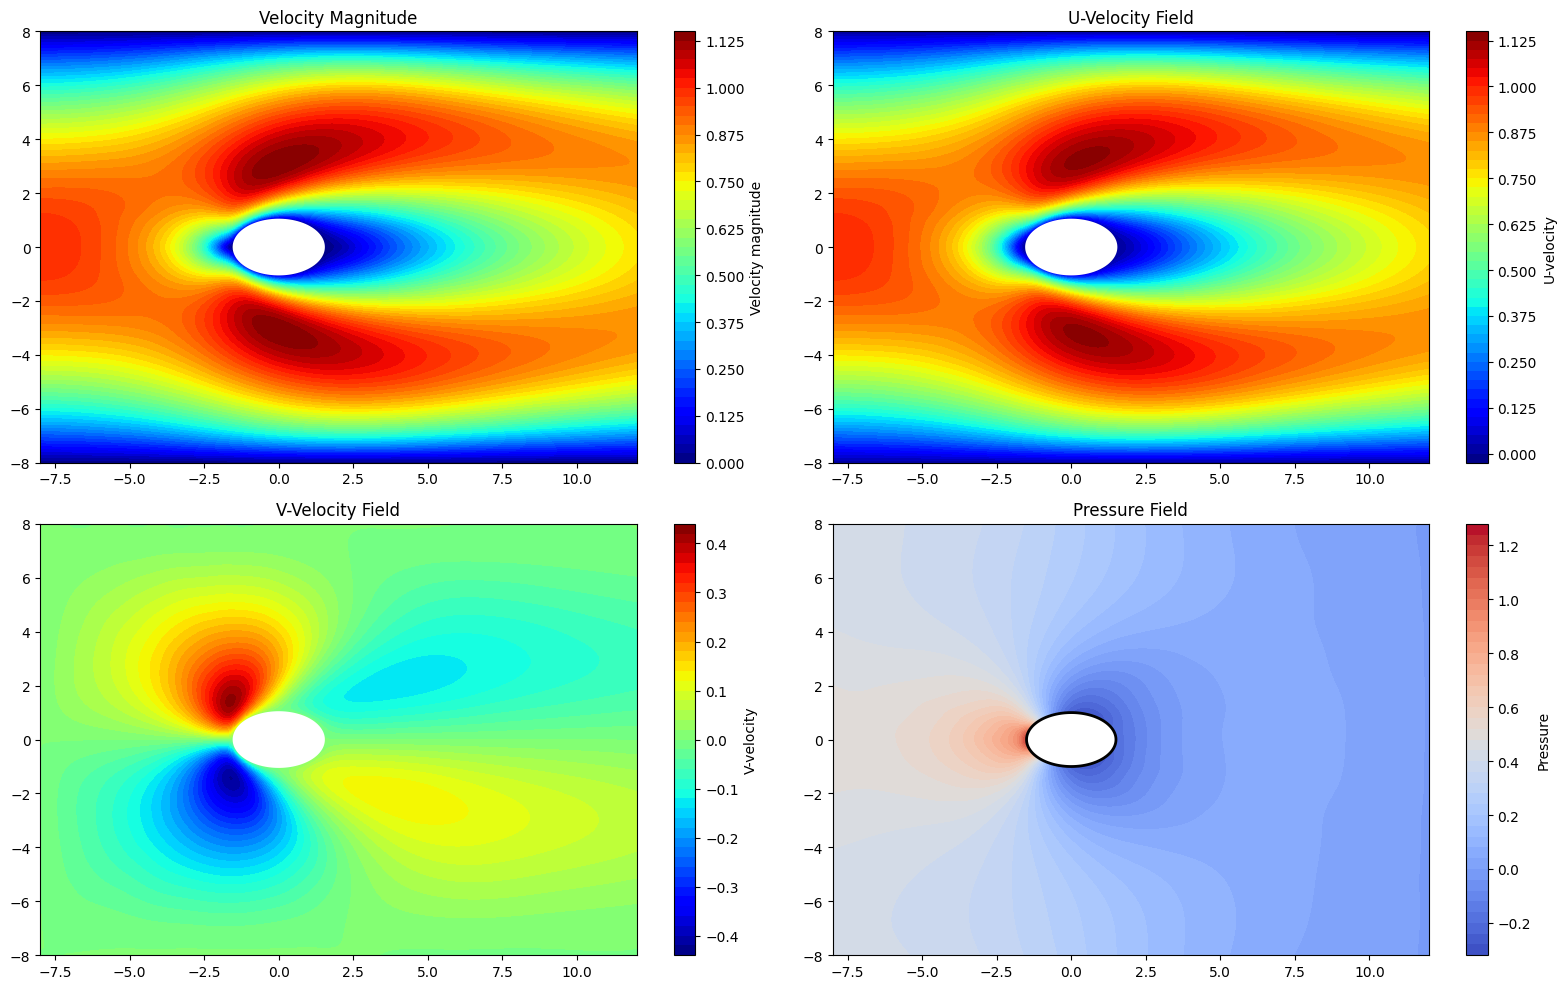

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = torch.load(r"C:\Users\mehul\MyLab\GSOC\shape optimization\Task Report stuff\Models\Fourier_epoch - 30000.pth").to(device)
model.eval() 
        
x_grid = np.linspace(-12, 16, 560)
y_grid = np.linspace(-8, 8, 320)
X, Y = np.meshgrid(x_grid, y_grid)


x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device).requires_grad_(True)
y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32, device=device).requires_grad_(True)

a_val, b_val, n_val = 1.5, 1.0, 2.0 # fixed shape params
a_test = torch.full_like(x_flat, a_val)
b_test = torch.full_like(x_flat, b_val)
n_test = torch.full_like(x_flat, n_val)

eps = 1e-6
sdf_flat = torch.pow((torch.abs(x_flat/a_test) + eps)**n_test + 
                     (torch.abs(y_flat/b_test) + eps)**n_test, 1/n_test) - 1.0

u, v, p, psi, s11, s22, s12 = model(x_flat, y_flat, a_test, b_test, n_test,sdf_flat)

U = u.detach().cpu().numpy().reshape(320, 560)
V = v.detach().cpu().numpy().reshape(320, 560)
P = p.detach().cpu().numpy().reshape(320, 560)
SDF = sdf_flat.detach().cpu().numpy().reshape(320, 560)

vel_mag = np.sqrt(U**2 + V**2)
u_only = U.copy()
v_only = V.copy()

# masking the insides of the obstacle :
u_only[SDF < 0] = np.nan
v_only[SDF < 0] = np.nan
vel_mag[SDF < 0] = np.nan
P[SDF < 0] = np.nan

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Velocity Magnitude
c1 = axes[0, 0].contourf(X, Y, vel_mag, levels=50, cmap='jet')
axes[0, 0].contour(X, Y, SDF, levels=[0], colors='white', linewidths=2)
fig.colorbar(c1, ax=axes[0, 0], label='Velocity magnitude')
axes[0, 0].set_title(f"Velocity Magnitude")

# U-velocity
c2 = axes[0, 1].contourf(X, Y, u_only, levels=50, cmap='jet')
axes[0, 1].contour(X, Y, SDF, levels=[0], colors='white', linewidths=2)
fig.colorbar(c2, ax=axes[0, 1], label='U-velocity')
axes[0, 1].set_title("U-Velocity Field")

# V-velocity
c3 = axes[1, 0].contourf(X, Y, v_only, levels=50, cmap='jet')
axes[1, 0].contour(X, Y, SDF, levels=[0], colors='white', linewidths=2)
fig.colorbar(c3, ax=axes[1, 0], label='V-velocity')
axes[1, 0].set_title("V-Velocity Field")

# Pressure
c4 = axes[1, 1].contourf(X, Y, P, levels=50, cmap='coolwarm')
axes[1, 1].contour(X, Y, SDF, levels=[0], colors='black', linewidths=2)
fig.colorbar(c4, ax=axes[1, 1], label='Pressure')
axes[1, 1].set_title("Pressure Field")

for ax in axes.flatten():
    ax.set_xlim(-8, 12)
    ax.set_ylim(-8, 8)

plt.tight_layout()
plt.show()

## saving the results for evaluation:

In [11]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = torch.load(r"C:\Users\mehul\MyLab\GSOC\shape optimization\Task Report stuff\Models\Fourier_epoch - 30000.pth").to(device)
model.eval()


x_grid = np.linspace(-8, 12, 400)
y_grid = np.linspace(-8, 8, 320)
X, Y = np.meshgrid(x_grid, y_grid)

x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device).requires_grad_(True)
y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32, device=device).requires_grad_(True)

a_val, b_val, n_val = 1.5, 1.0, 2.0
a_test = torch.full_like(x_flat, a_val)
b_test = torch.full_like(x_flat, b_val)
n_test = torch.full_like(x_flat, n_val)


eps = 1e-6
sdf_flat = torch.pow((torch.abs(x_flat/a_test) + eps)**n_test + 
                     (torch.abs(y_flat/b_test) + eps)**n_test, 1/n_test) - 1.0

u, v, p, psi, s11, s22, s12 = model(x_flat, y_flat, a_test, b_test, n_test, sdf_flat)

U_pred = u.detach().cpu().numpy().reshape(320, 400)
V_pred = v.detach().cpu().numpy().reshape(320, 400)
P_pred = p.detach().cpu().numpy().reshape(320, 400)
SDF = sdf_flat.detach().cpu().numpy().reshape(320, 400)


# masking the insides of the obstacle :
U_pred[SDF < 0] = np.nan
V_pred[SDF < 0] = np.nan
P_pred[SDF < 0] = np.nan



np.save("U_pinn.npy", U_pred)
np.save("V_pinn.npy", V_pred)
np.save("P_pinn.npy", P_pred)

print(f"Generated arrays of shape: {U_pred.shape}")


C:\Users\mehul\AppData\Local\Temp\ipykernel_24524\1364220125.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(r"C:\Users\mehul\MyLab\GSOC\shape optimiz

Generated arrays of shape: (320, 400)


In [ ]:

P_ref = np.load("C:\\Users\\mehul\\MyLab\\GSOC\\shape optimization\\Task Report stuff\\high fidelity dataset\\P_fenics.npy")
U_ref = np.load("C:\\Users\\mehul\\MyLab\\GSOC\\shape optimization\\Task Report stuff\\high fidelity dataset\\U_fenics.npy")
V_ref = np.load("C:\\Users\\mehul\\MyLab\\GSOC\\shape optimization\\Task Report stuff\\high fidelity dataset\\V_fenics.npy")
print(P_ref.shape)
print(U_ref.shape)
print(V_ref.shape)

## Evaluation with Ground Truth:


--- Relative L2 Errors ---
U-Velocity Error: 1.1624e-02 (1.16%)
V-Velocity Error: 4.9744e-02 (4.97%)
Pressure Error:   4.8731e-02 (4.87%)


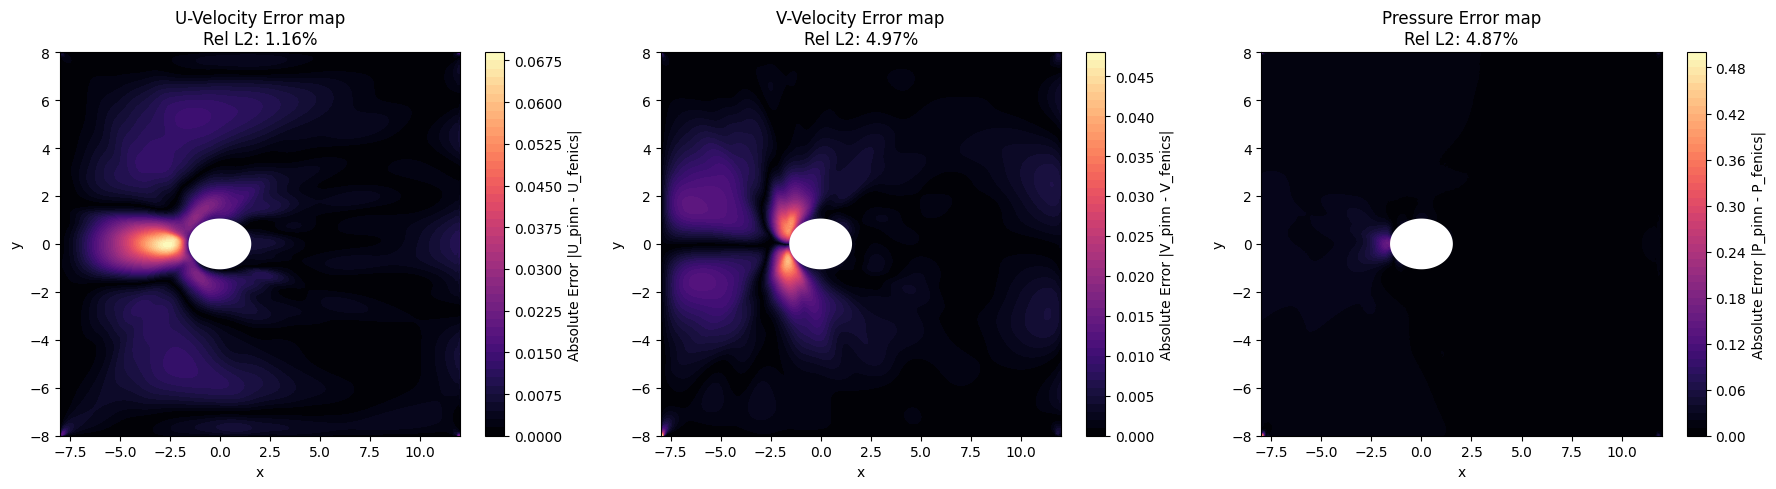

In [12]:

import numpy as np
import matplotlib.pyplot as plt

# PINN Predictions: 
U_pinn = np.load(r"C:\Users\mehul\MyLab\GSOC\shape optimization\Task Report stuff\U_pinn.npy")
V_pinn = np.load(r"C:\Users\mehul\MyLab\GSOC\shape optimization\Task Report stuff\V_pinn.npy")
P_pinn = np.load(r"C:\Users\mehul\MyLab\GSOC\shape optimization\Task Report stuff\P_pinn.npy")

# FEniCS Ground Truth: 
U_fenics = np.load(r"C:\Users\mehul\MyLab\GSOC\shape optimization\Task Report stuff\high fidelity dataset\U_fenics.npy")
V_fenics = np.load(r"C:\Users\mehul\MyLab\GSOC\shape optimization\Task Report stuff\high fidelity dataset\V_fenics.npy")
P_fenics = np.load(r"C:\Users\mehul\MyLab\GSOC\shape optimization\Task Report stuff\high fidelity dataset\P_fenics.npy")


def l2_error(pred, true):
   
    mask = ~np.isnan(true) & ~np.isnan(pred) # we dot consider the insides of the obstacle
    
    l2_diff = np.sqrt(np.sum((pred[mask] - true[mask])**2))
    l2_true = np.sqrt(np.sum((true[mask])**2))
    
    return l2_diff / l2_true



error_l2_U = l2_error(U_pinn, U_fenics)
error_l2_V = l2_error(V_pinn, V_fenics)
error_l2_P = l2_error(P_pinn, P_fenics)

print(f"--- Relative L2 Errors ---")
print(f"U-Velocity Error: {error_l2_U:.4e} ({error_l2_U*100:.2f}%)")
print(f"V-Velocity Error: {error_l2_V:.4e} ({error_l2_V*100:.2f}%)")
print(f"Pressure Error:   {error_l2_P:.4e} ({error_l2_P*100:.2f}%)")

# Absolute error maps :
abs_err_U = np.abs(U_pinn - U_fenics)
abs_err_V = np.abs(V_pinn - V_fenics)
abs_err_P = np.abs(P_pinn - P_fenics)


x_grid = np.linspace(-8, 12, 400)
y_grid = np.linspace(-8, 8, 320)
X, Y = np.meshgrid(x_grid, y_grid)

eps = 1e-6
SDF = np.power((np.abs(X/1.5) + eps)**2.0 + (np.abs(Y/1.0) + eps)**2.0, 1/2.0) - 1.0







fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cmap_error = 'magma'

# Plot U Error:
c1 = axes[0].contourf(X, Y, abs_err_U, levels=50, cmap=cmap_error)
axes[0].contour(X, Y, SDF, levels=[0], colors='white', linewidths=2) # Draw obstacle
fig.colorbar(c1, ax=axes[0], label='Absolute Error |U_pinn - U_fenics|')
axes[0].set_title(f"U-Velocity Error map\nRel L2: {error_l2_U:.2%}")

# Plot V Error: 
c2 = axes[1].contourf(X, Y, abs_err_V, levels=50, cmap=cmap_error)
axes[1].contour(X, Y, SDF, levels=[0], colors='white', linewidths=2)
fig.colorbar(c2, ax=axes[1], label='Absolute Error |V_pinn - V_fenics|')
axes[1].set_title(f"V-Velocity Error map\nRel L2: {error_l2_V:.2%}")

# Plot P Error: 
c3 = axes[2].contourf(X, Y, abs_err_P, levels=50, cmap=cmap_error)
axes[2].contour(X, Y, SDF, levels=[0], colors='white', linewidths=2)
fig.colorbar(c3, ax=axes[2], label='Absolute Error |P_pinn - P_fenics|')
axes[2].set_title(f"Pressure Error map\nRel L2: {error_l2_P:.2%}")


for ax in axes:
    ax.set_xlim(-8, 12)
    ax.set_ylim(-8, 8)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.savefig("PINN_Error_Analysis.png", dpi=300, bbox_inches='tight')
plt.show()